## 4.1 Definirea problemei

In cadrul acestui proiect am analizat problema aprobarii creditelor pe baza caracteristicilor solicitantilor. Scopul este de a construi modele de machine learning capabile sa prezica daca un credit va fi aprobat sau nu, folosind datele disponibile.

Problema abordata este una de clasificare, deoarece variabila de iesire este categorica. Am urmarit prezicerea variabilei Loan_Status, care indica daca un credit este aprobat (Y) sau respins (N).

Variabilele de intrare includ caracteristici precum venitul solicitantului, istoricul de credit (Credit_History), suma imprumutului (LoanAmount), durata imprumutului si alte informatii relevante.

Variabila de iesire este Loan_Status, care a fost transformata in valori binare (1 – aprobat, 0 – respins).

Am ales acest set de date deoarece reprezinta o problema reala din domeniul financiar si permite analiza si compararea performantelor mai multor algoritmi de clasificare.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from interpret.glassbox import ExplainableBoostingClassifier


D:\university_sem2_3rd_year\is\Ass1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4.2 Analiza exploratorie a datelor si pregatirea lor

In aceasta etapa am realizat o analiza exploratorie a datelor (EDA) pentru a intelege structura, distributia si relatiile dintre variabile.

Datasetul contine atat variabile numerice, cat si categorice, fiind necesara transformarea acestora pentru a putea fi utilizate in modele de machine learning.

Distribuția variabilei tinta arata ca majoritatea creditelor sunt aprobate, ceea ce indica un dezechilibru intre clase. Acest lucru poate influenta performanta modelelor, in special pentru clasa negativa.

Matricea de corelatii arata ca variabila Credit_History are cea mai puternica relatie pozitiva cu aprobarea creditului. De asemenea, venitul si suma imprumutului au influente moderate asupra rezultatului.

Valorile lipsa au fost tratate prin inlocuire cu moda, iar variabilele categorice au fost transformate folosind one-hot encoding.

Datele au fost impartite in set de antrenare (75%) si testare (25%). Pentru modelele sensibile la scala datelor (SVM, KNN, Logistic Regression), am aplicat standardizarea folosind StandardScaler.

In [2]:
df = pd.read_csv("loan-prediction.csv")

print(df.head())
print(df.info())
print(df.describe())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural           N  
2             1.0   

In [3]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

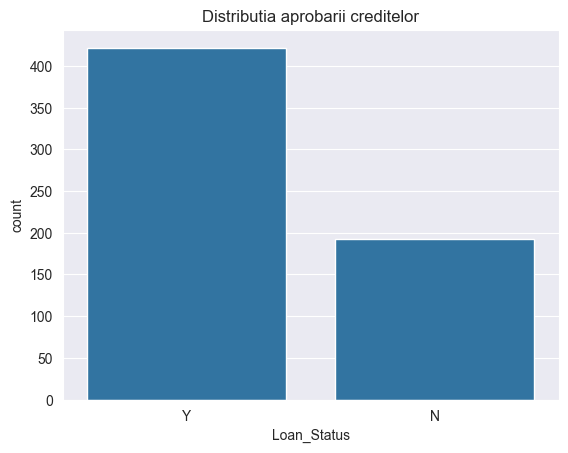

In [4]:
sns.countplot(x="Loan_Status", data=df)
plt.title("Distributia aprobarii creditelor")
plt.show()

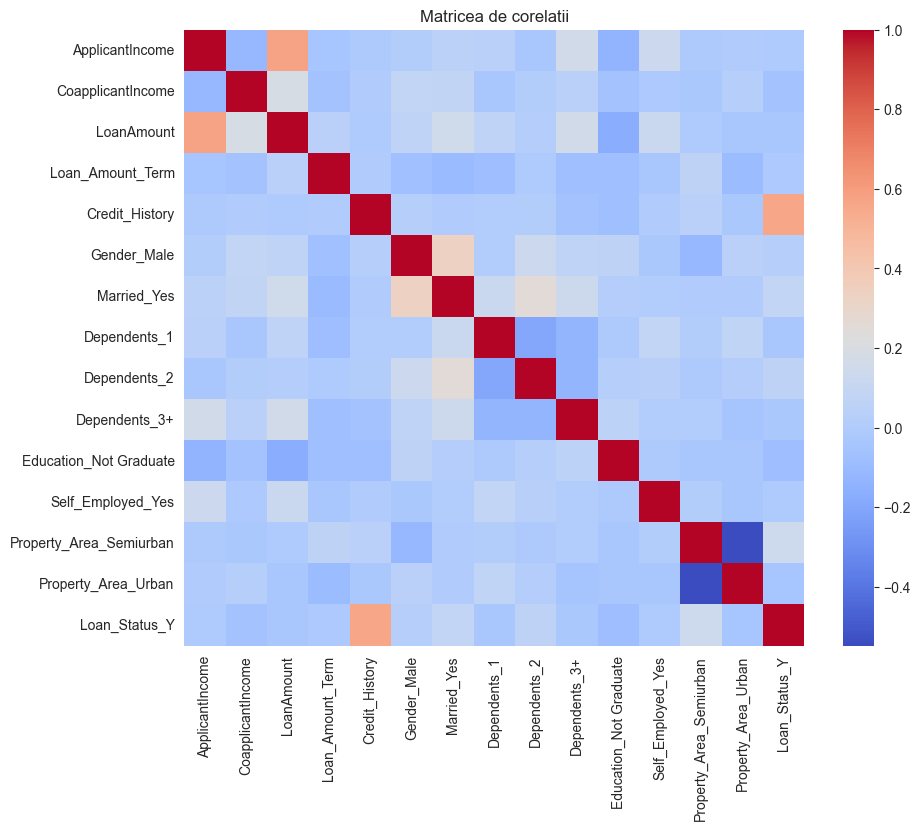

In [5]:
df = df.drop("Loan_ID", axis=1)

df_temp = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(10,8))
sns.heatmap(df_temp.corr(), cmap="coolwarm")
plt.title("Matricea de corelatii")
plt.show()

In [6]:
df["Loan_Status"] = df["Loan_Status"].map({"Y": 1, "N": 0})
df.fillna(df.mode().iloc[0], inplace=True)
df = pd.get_dummies(df, drop_first=True)

In [7]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, random_state=42)

In [8]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

In [9]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

# verifica daca modelul are probabilitati
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = y_pred

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }

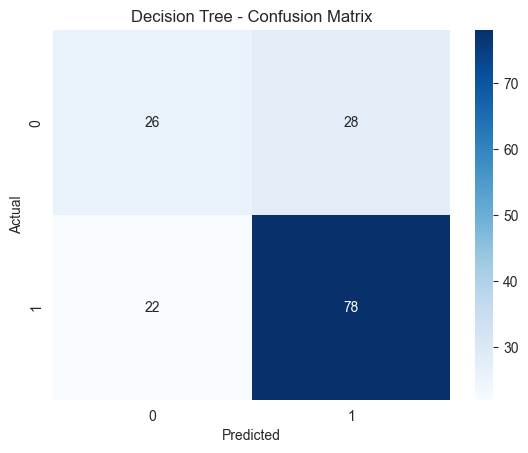

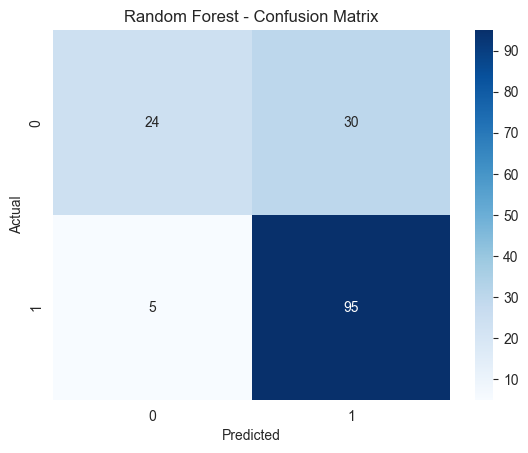

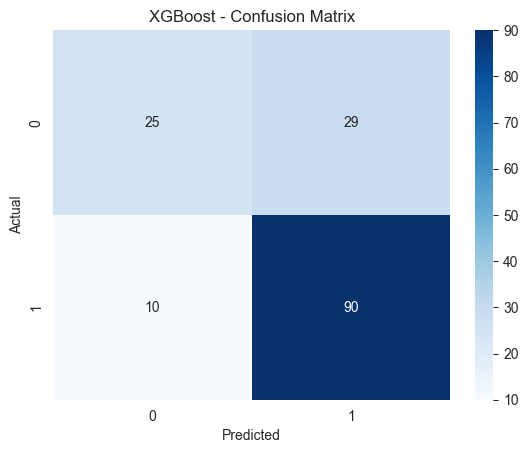

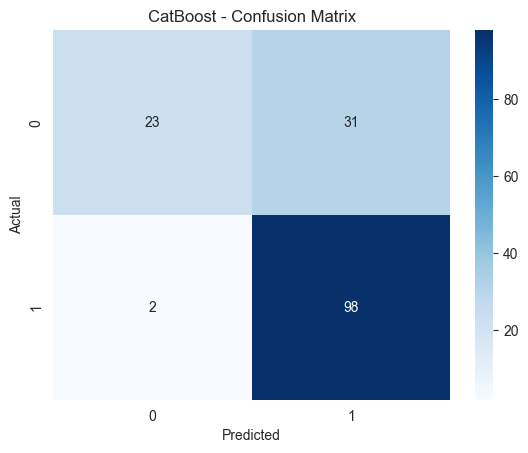

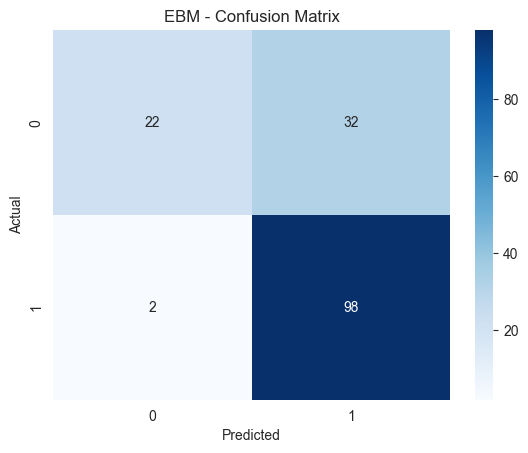

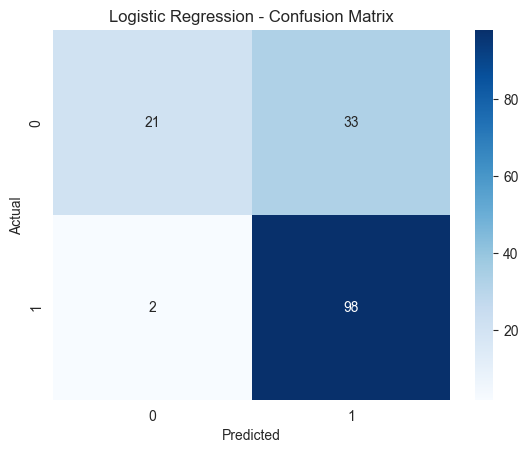

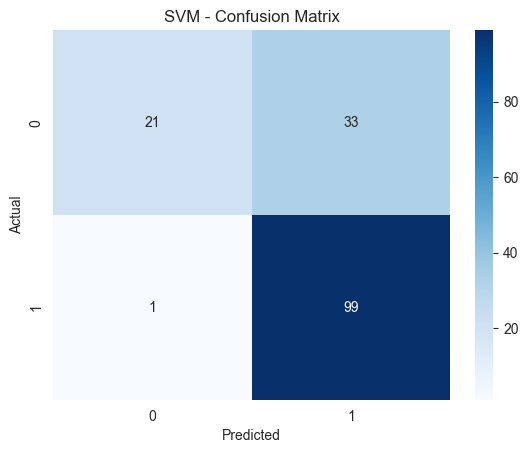

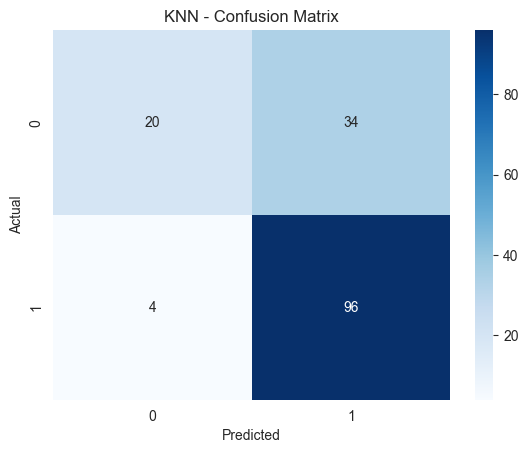

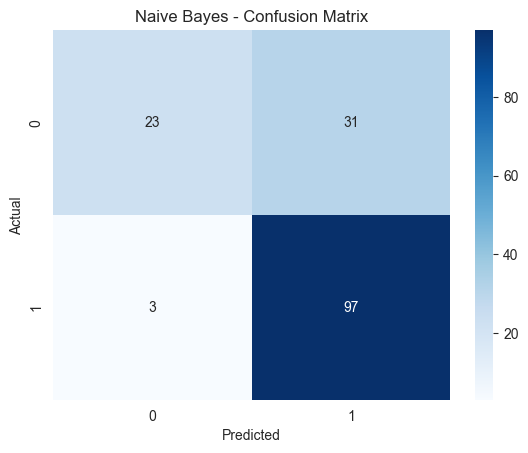

In [10]:
results = []

# fara scaling
results.append(evaluate_model("Decision Tree", DecisionTreeClassifier(random_state=42), X_train, X_test, y_train, y_test))
results.append(evaluate_model("Random Forest", RandomForestClassifier(random_state=42), X_train, X_test, y_train, y_test))
results.append(evaluate_model("XGBoost", XGBClassifier(eval_metric='logloss',  random_state=42), X_train, X_test, y_train, y_test))
results.append(evaluate_model("CatBoost", CatBoostClassifier(verbose=0), X_train, X_test, y_train, y_test))
results.append(evaluate_model("EBM", ExplainableBoostingClassifier(), X_train, X_test, y_train, y_test))

# cu scaling
results.append(evaluate_model("Logistic Regression", LogisticRegression(max_iter=2000), X_train_scaled, X_test_scaled, y_train, y_test))
results.append(evaluate_model("SVM", SVC(probability=True), X_train_scaled, X_test_scaled, y_train, y_test))
results.append(evaluate_model("KNN", KNeighborsClassifier(), X_train_scaled, X_test_scaled, y_train, y_test))
results.append(evaluate_model("Naive Bayes", GaussianNB(), X_train_scaled, X_test_scaled, y_train, y_test))


In [11]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1", ascending=False)

print(results_df)

                 Model  Accuracy  Precision  Recall        F1   ROC_AUC
3             CatBoost  0.785714   0.759690    0.98  0.855895  0.760000
6                  SVM  0.779221   0.750000    0.99  0.853448  0.756667
4                  EBM  0.779221   0.753846    0.98  0.852174  0.749815
8          Naive Bayes  0.779221   0.757812    0.97  0.850877  0.761296
5  Logistic Regression  0.772727   0.748092    0.98  0.848485  0.739444
1        Random Forest  0.772727   0.760000    0.95  0.844444  0.783796
7                  KNN  0.753247   0.738462    0.96  0.834783  0.708611
2              XGBoost  0.746753   0.756303    0.90  0.821918  0.742778
0        Decision Tree  0.675325   0.735849    0.78  0.757282  0.630741


In [12]:
top5 = results_df.head(5)

print("TOP 5 MODELE:")
print(top5)

TOP 5 MODELE:
                 Model  Accuracy  Precision  Recall        F1   ROC_AUC
3             CatBoost  0.785714   0.759690    0.98  0.855895  0.760000
6                  SVM  0.779221   0.750000    0.99  0.853448  0.756667
4                  EBM  0.779221   0.753846    0.98  0.852174  0.749815
8          Naive Bayes  0.779221   0.757812    0.97  0.850877  0.761296
5  Logistic Regression  0.772727   0.748092    0.98  0.848485  0.739444


## 4.3 Antrenarea si compararea modelelor de baza

Din rezultatele obtinute se observa ca modelele precum CatBoost, SVM si EBM au obtinut cele mai bune performante, avand valori ridicate pentru F1 si ROC-AUC.

Modelele precum Random Forest, XGBoost, CatBoost au avut performante bune, datorita capacitatii de a captura relatii complexe din date.

Modelele mai simple, precum Logistic Regression si Naive Bayes, au avut performante competitive, dar usor mai reduse.

Decision Tree a avut cele mai slabe rezultate, probabil din cauza overfitting-ului si a generalizarii slabe pe datele de test.

In general, majoritatea modelelor au obtinut un recall ridicat, ceea ce indica o buna capacitate de a identifica creditele aprobate.

In [13]:
def tune_model(name, model, param_grid, X_train, y_train):
    grid = GridSearchCV(
        model,
        param_grid,
        cv=3,
        scoring='f1',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    print(f"{name} BEST PARAMS:", grid.best_params_)

    return grid.best_estimator_

In [14]:
lr_params = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

lr_best = tune_model( "Logistic Regression", LogisticRegression(max_iter=2000), lr_params, X_train_scaled, y_train)

Logistic Regression BEST PARAMS: {'C': 0.1, 'solver': 'liblinear'}


In [15]:
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear']
}

svm_best = tune_model("SVM", SVC(probability=True), svm_params,  X_train_scaled, y_train)

SVM BEST PARAMS: {'C': 0.1, 'kernel': 'linear'}


In [16]:
cat_params = {
    'depth': [4, 6],
    'learning_rate': [0.03, 0.1],
    'iterations': [100, 200]
}

cat_best = tune_model("CatBoost",CatBoostClassifier(verbose=0),cat_params,X_train,y_train)

CatBoost BEST PARAMS: {'depth': 4, 'iterations': 100, 'learning_rate': 0.03}


In [17]:
ebm_params = {
    'max_bins': [128, 256],
    'learning_rate': [0.01, 0.05],
    'interactions': [0]
}

ebm_best = tune_model( "EBM",ExplainableBoostingClassifier(interactions=0),ebm_params,X_train,y_train)

EBM BEST PARAMS: {'interactions': 0, 'learning_rate': 0.01, 'max_bins': 128}


In [18]:
nb_params = {
    'var_smoothing': [1e-9, 1e-8, 1e-7]
}

nb_best = tune_model("Naive Bayes",GaussianNB(),nb_params,X_train_scaled,y_train)

Naive Bayes BEST PARAMS: {'var_smoothing': 1e-09}


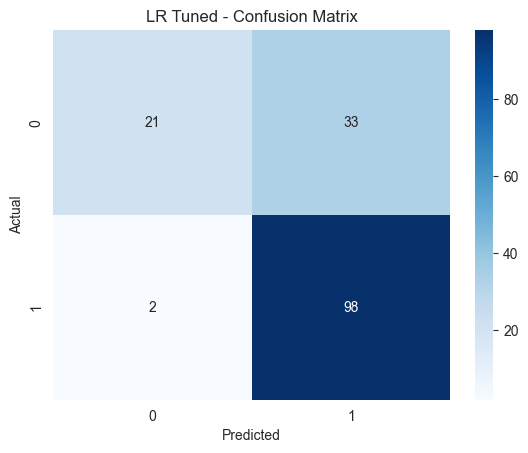

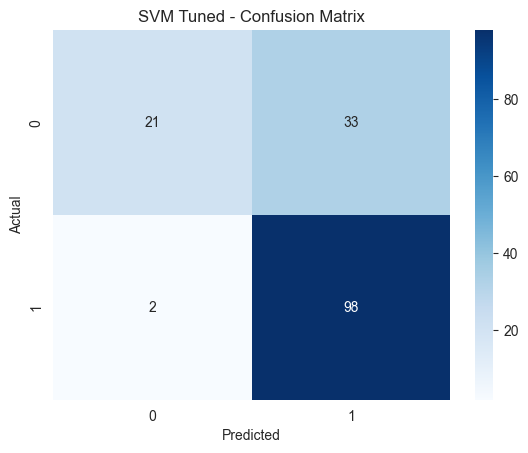

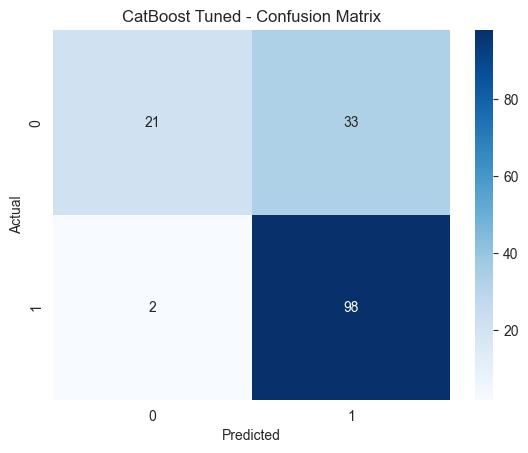

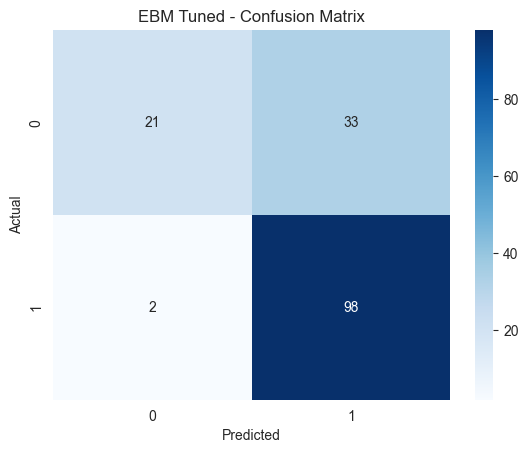

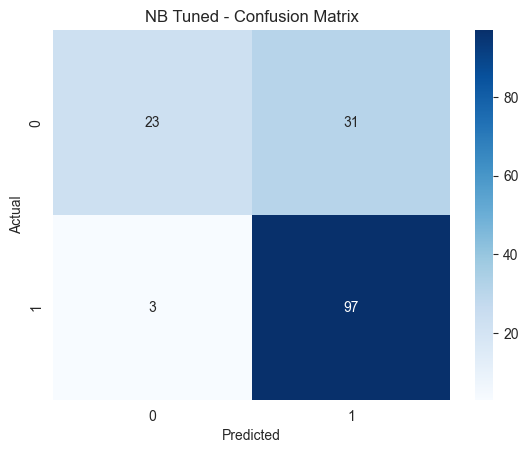

            Model  Accuracy  Precision  Recall        F1   ROC_AUC
4        NB Tuned  0.779221   0.757812    0.97  0.850877  0.761296
0        LR Tuned  0.772727   0.748092    0.98  0.848485  0.744074
1       SVM Tuned  0.772727   0.748092    0.98  0.848485  0.739630
2  CatBoost Tuned  0.772727   0.748092    0.98  0.848485  0.738519
3       EBM Tuned  0.772727   0.748092    0.98  0.848485  0.716111


In [19]:
tuned_results = []

tuned_results.append(evaluate_model("LR Tuned", lr_best, X_train_scaled, X_test_scaled, y_train, y_test))
tuned_results.append(evaluate_model("SVM Tuned", svm_best, X_train_scaled, X_test_scaled, y_train, y_test))
tuned_results.append(evaluate_model("CatBoost Tuned", cat_best, X_train, X_test, y_train, y_test))
tuned_results.append(evaluate_model("EBM Tuned", ebm_best, X_train, X_test, y_train, y_test))
tuned_results.append(evaluate_model("NB Tuned", nb_best, X_train_scaled, X_test_scaled, y_train, y_test))

tuned_df = pd.DataFrame(tuned_results).sort_values(by="F1", ascending=False)

print(tuned_df)

## 4.4 Ajustarea hiperparametrilor

Pentru imbunatatirea performantelor, am utilizat metoda GridSearchCV pentru selectarea celor mai bune combinatii de hiperparametri.

Pentru fiecare model au fost definite intervale relevante de valori pentru hiperparametri, tinand cont de rolul acestora in controlul complexitatii modelului.

Am avut in vedere evitarea overfitting-ului prin alegerea unor valori optime pentru parametri precum C (pentru SVM si Logistic Regression) sau depth (pentru CatBoost).

### Analiza rezultatelor dupa tuning

In urma ajustarii hiperparametrilor, imbunatatirile obtinute sunt relativ reduse, ceea ce indica faptul ca modelele initiale aveau deja performante bune.

Cele mai bune rezultate dupa tuning au fost obtinute de modelele **EBM, Naive Bayes si Logistic Regression**, care au inregistrat cele mai mari valori ale scorului F1.

Acest rezultat sugereaza ca modele mai simple sau mai bine regularizate pot generaliza mai bine pe acest dataset, comparativ cu modelele mai complexe.

Unele modele nu au inregistrat imbunatatiri semnificative, sugerand ca setarile implicite erau deja bine adaptate pentru datele analizate.

In [20]:
def plot_learning_curve(model, title, X, y):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring='f1',  #combinatie intre precision si recall
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, label="Train")
    plt.plot(train_sizes, val_mean, label="Validation")
    plt.title(title)
    plt.xlabel("Training size")
    plt.ylabel("F1 score")
    plt.legend()
    plt.show()

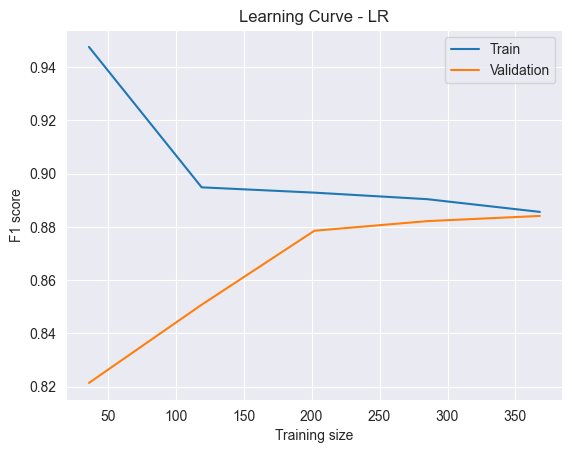

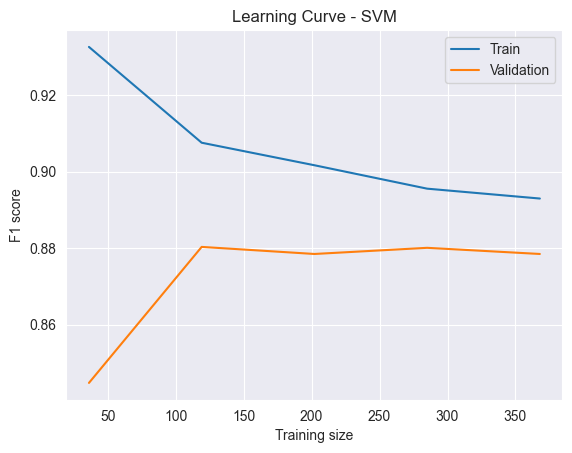

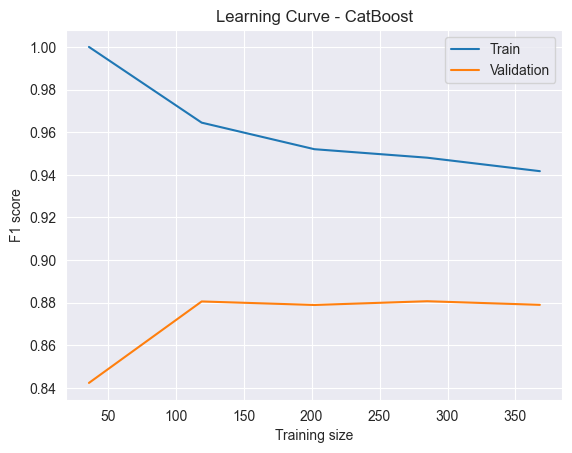

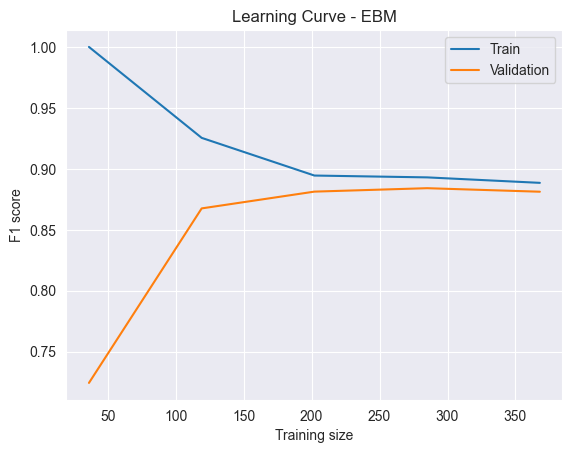

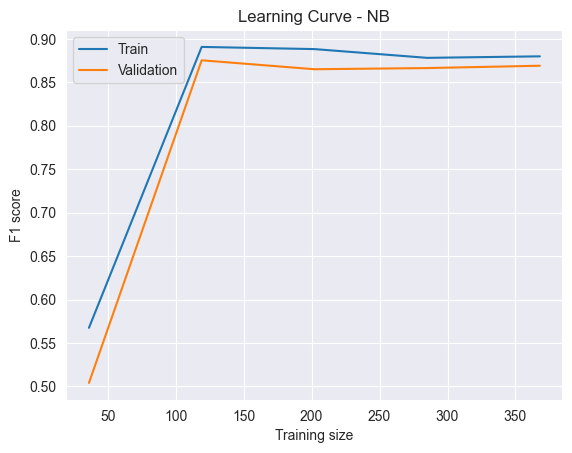

In [21]:
# Logistic Regression
plot_learning_curve(LogisticRegression(max_iter=2000), "Learning Curve - LR", X_train_scaled, y_train)

# SVM
plot_learning_curve(SVC(probability=True), "Learning Curve - SVM", X_train_scaled, y_train)

# CatBoost
plot_learning_curve(CatBoostClassifier(verbose=0), "Learning Curve - CatBoost", X_train, y_train)

# EBM
plot_learning_curve(ExplainableBoostingClassifier(), "Learning Curve - EBM", X_train, y_train)

# Naive Bayes
plot_learning_curve(GaussianNB(), "Learning Curve - NB", X_train_scaled, y_train)

## 4.5 Curbele de invatare - analiza

Din graficele obtinute se observa ca pentru majoritatea modelelor diferenta dintre scorul pe setul de antrenare si cel de validare este relativ mica, ceea ce indica o buna capacitate de generalizare.

Pentru Logistic Regression, curbele de train si validation sunt apropiate si tind sa se stabilizeze, ceea ce sugereaza un model bine echilibrat, fara overfitting semnificativ.

In cazul SVM, se observa un comportament similar, cu o diferenta mica intre cele doua curbe. Modelul generalizeaza bine, dar performanta este usor mai scazuta comparativ cu alte modele.

Pentru CatBoost, scorul pe setul de antrenare este foarte ridicat, in timp ce scorul pe validare este mai mic, ceea ce indica o usoara tendinta de overfitting.

Modelul EBM prezinta un comportament echilibrat, cu o diferenta moderata intre train si validation, sugerand un compromis bun intre complexitate si generalizare.

Naive Bayes are curbele foarte apropiate, ceea ce indica lipsa overfitting-ului, insa performanta sa este limitata de simplitatea modelului.

In general, nu se observa underfitting, iar majoritatea modelelor reusesc sa invete eficient din date.

## 4.6 Explicabilitatea si analiza SHAP

Analiza a fost efectuata pentru primele 3 modele dupa performanta: Random Forest ,CatBoost si SVR si am urmarit diferenta dintre acestea prin rezultatele graficelor.

In [22]:
explainer_lr = shap.Explainer(lr_best, X_train_scaled)
shap_values_lr = explainer_lr(X_test_scaled)

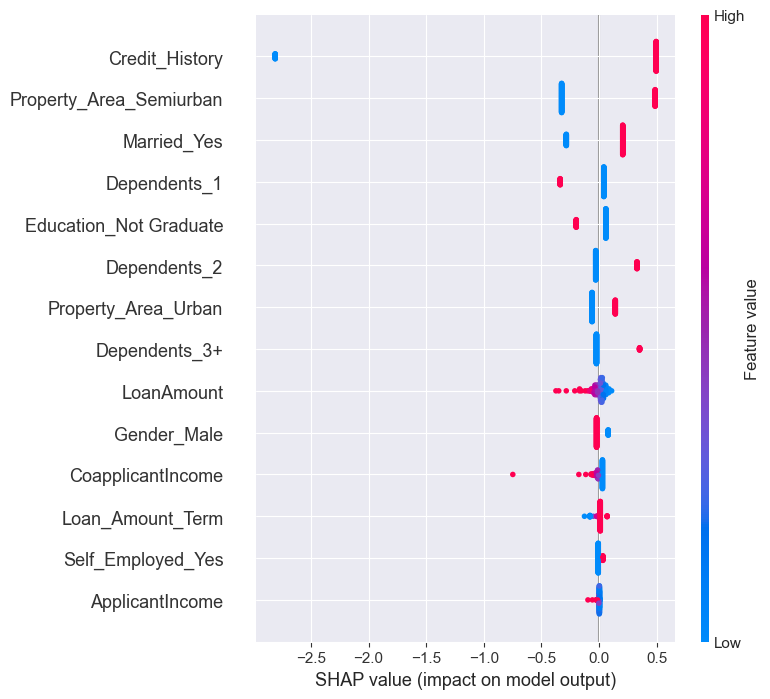

In [23]:
shap.summary_plot(shap_values_lr, X_test_scaled)

Graficul summary arata ca Credit_History este cea mai importanta variabila pentru modelul Logistic Regression, urmata de Property_Area_Semiurban.
Valorile mari cresc semnificativ probabilitatea aprobarii, iar valorile mici o reduc.
Celelalte variabile au un impact redus si sunt concentrate in jurul valorii zero.

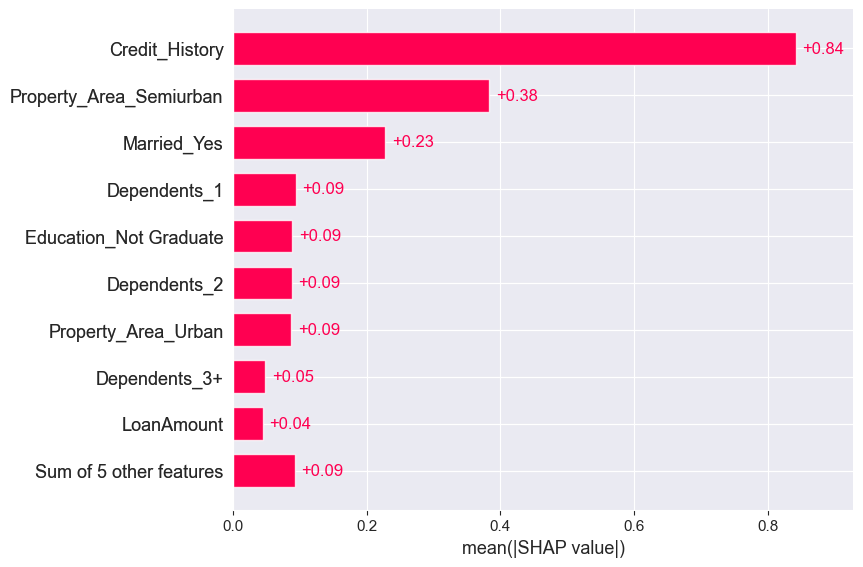

In [24]:
shap.plots.bar(shap_values_lr)

Graficul de tip bar confirma dominanta variabilei Credit_History.
Property_Area_Semiurban si Married_Yes au contributii moderate, iar restul caracteristicilor au influente minore.

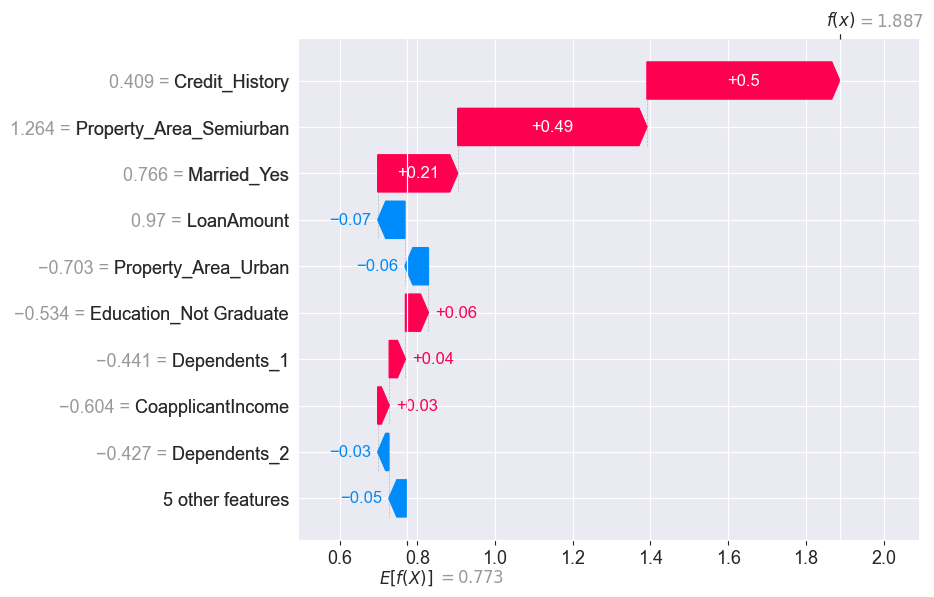

In [25]:
shap.initjs()
shap.plots.waterfall(shap_values_lr[0])
shap.plots.force(shap_values_lr[0])

Graficul waterfall evidentiaza contributiile caracteristicilor pentru o observatie.
Credit_History si Property_Area_Semiurban cresc predictia, in timp ce LoanAmount si Property_Area_Urban o reduc.
Rezultatul final este determinat de combinarea acestor influente.

Graficul force arata cum variabilele influenteaza predictia.
Caracteristicile pozitive cresc probabilitatea aprobarii, iar cele negative o reduc.
Credit_History are cel mai puternic impact pozitiv.

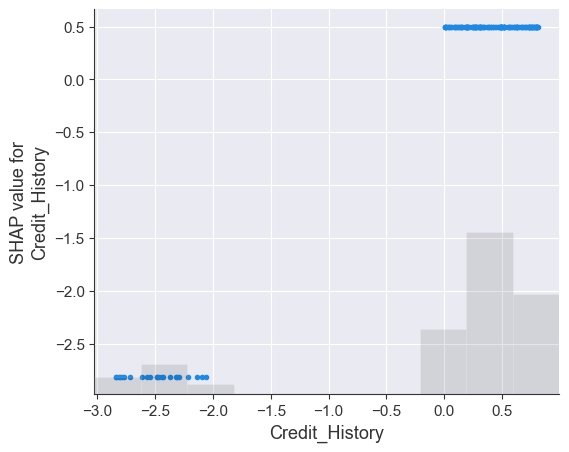

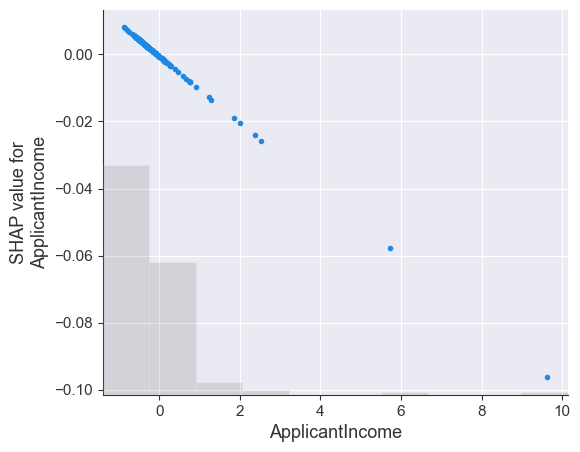

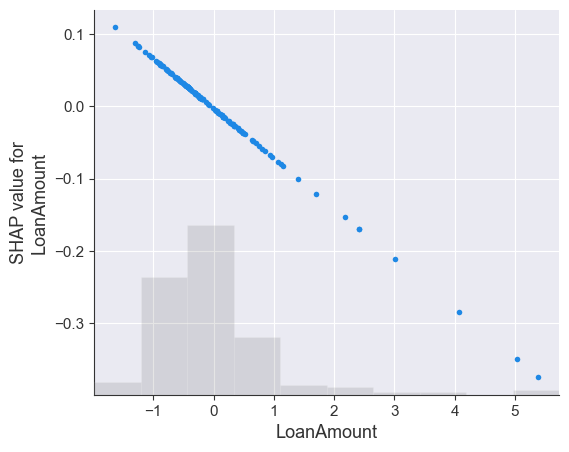

In [26]:
shap.plots.scatter(shap_values_lr[:, "Credit_History"])
shap.plots.scatter(shap_values_lr[:, "ApplicantIncome"])
shap.plots.scatter(shap_values_lr[:, "LoanAmount"])

Se observa o relatie clara intre Credit_History si predictie.
Valorile mari cresc probabilitatea aprobarii, iar valorile mici au un impact negativ puternic.

ApplicantIncome are o influenta redusa asupra modelului.
Se observa o usoara tendinta negativa, dar fara impact major.

LoanAmount are o relatie negativa cu predictia.
Valorile mari reduc probabilitatea aprobarii, dar influenta nu este foarte puternica.

In [27]:
explainer_nb = shap.KernelExplainer(
    nb_best.predict_proba,
    X_train_scaled[:100]   # subset (important pentru viteza)
)

shap_values_nb = explainer_nb.shap_values(X_test_scaled[:50])

100%|██████████| 50/50 [00:04<00:00, 10.36it/s]


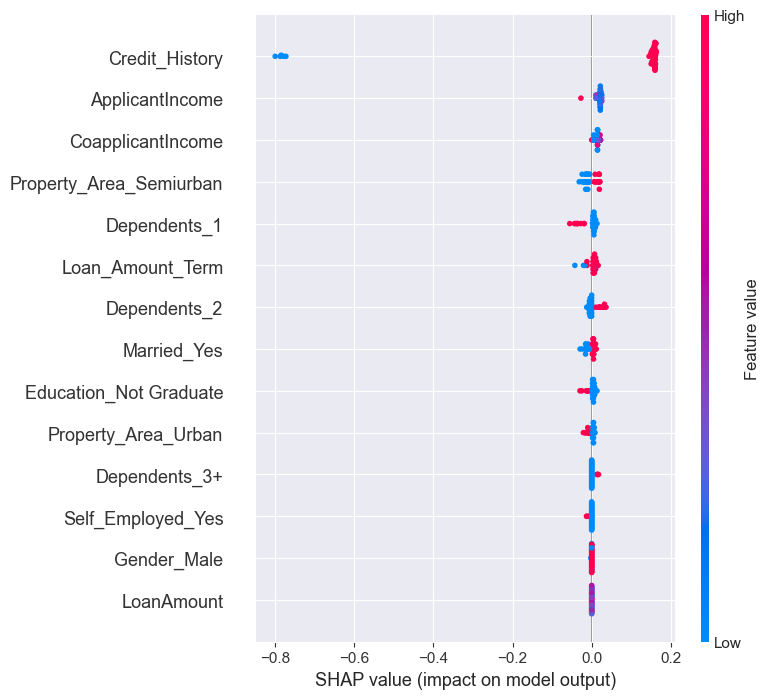

In [28]:
shap.summary_plot(shap_values_nb[:, :, 1], X_test_scaled[:50])

Graficul summary arata ca Credit_History este cea mai influenta variabila si in modelul Naive Bayes.
Restul caracteristicilor au impact mult mai redus si sunt apropiate de zero.

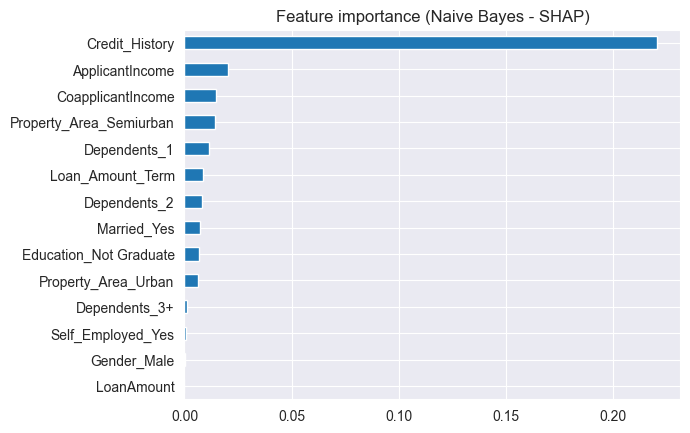

In [29]:
mean_abs_shap = np.abs(shap_values_nb[:, :, 1]).mean(axis=0)

feature_importance = pd.Series(mean_abs_shap, index=X_test_scaled.columns)
feature_importance.sort_values().plot(kind="barh")
plt.title("Feature importance (Naive Bayes - SHAP)")
plt.show()

Graficul confirma faptul ca modelul se bazeaza in principal pe Credit_History.
Celelalte variabile au contributii mici si similare.

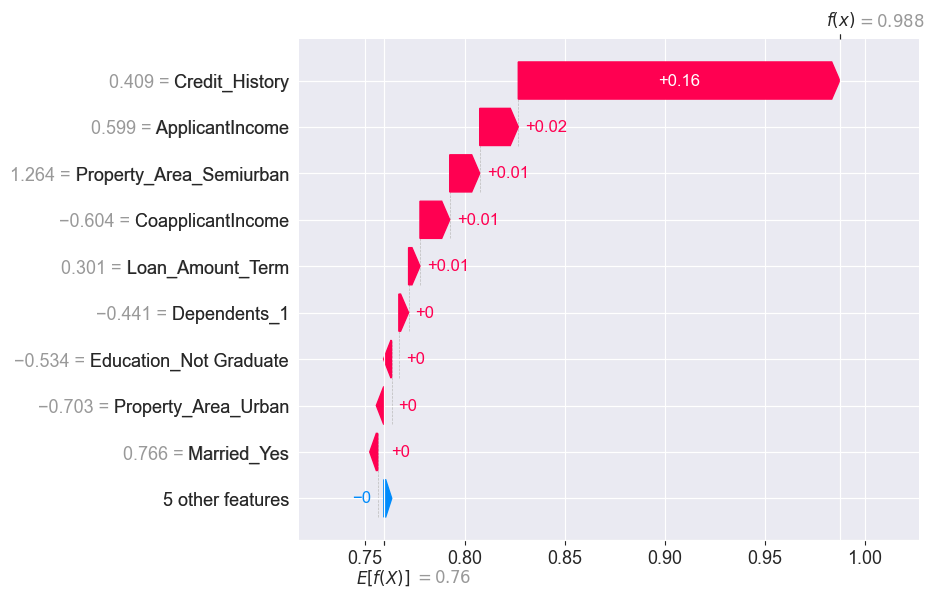

In [30]:
i = 0

expl = shap.Explanation(
    values=shap_values_nb[i, :, 1],
    base_values=explainer_nb.expected_value[1],
    data=X_test_scaled.iloc[i],
    feature_names=X_test_scaled.columns
)

shap.plots.waterfall(expl)

In acest exemplu, Credit_History are cea mai mare contributie pozitiva.
Celelalte variabile influenteaza rezultatul foarte putin.
Modelul depinde puternic de aceasta caracteristica.

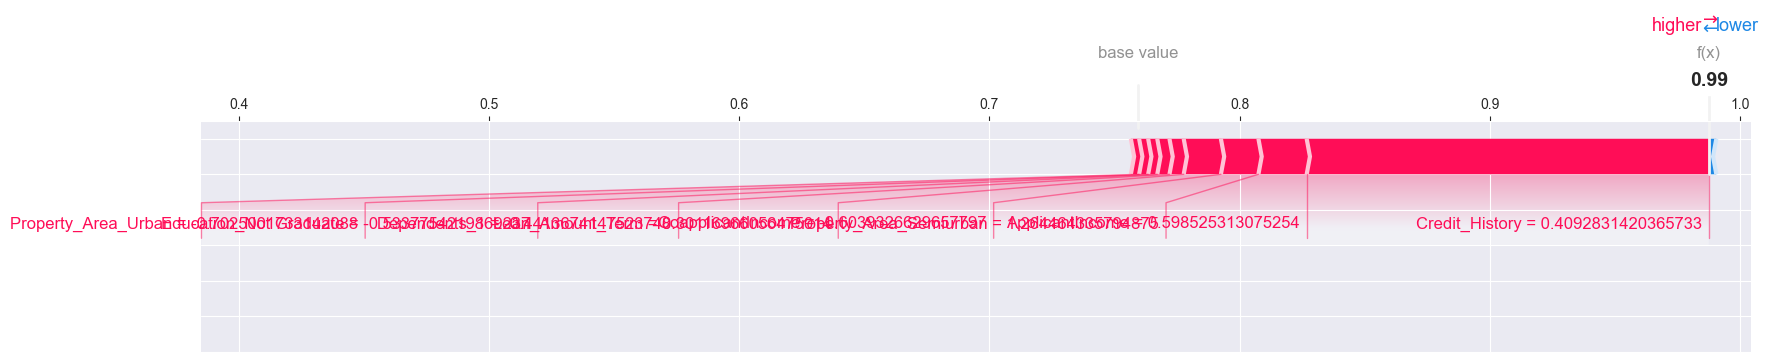

In [31]:
shap.force_plot(
    explainer_nb.expected_value[1],
    shap_values_nb[i, :, 1],
    X_test_scaled.iloc[i],
    matplotlib=True
)

Graficul force arata ca majoritatea influentei provine din Credit_History.
Celelalte caracteristici au efecte minore asupra predictiei.

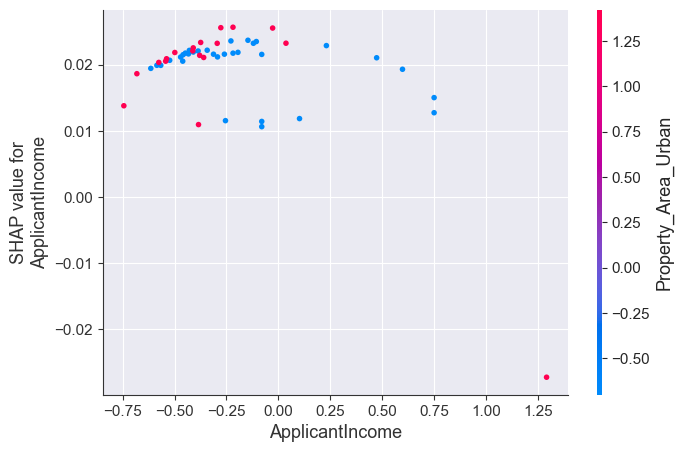

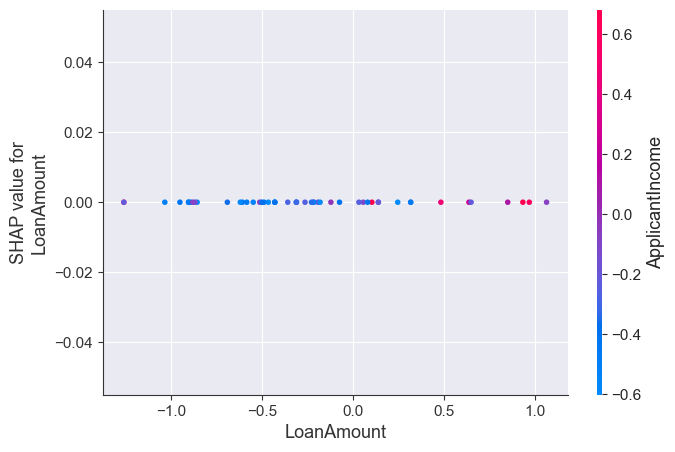

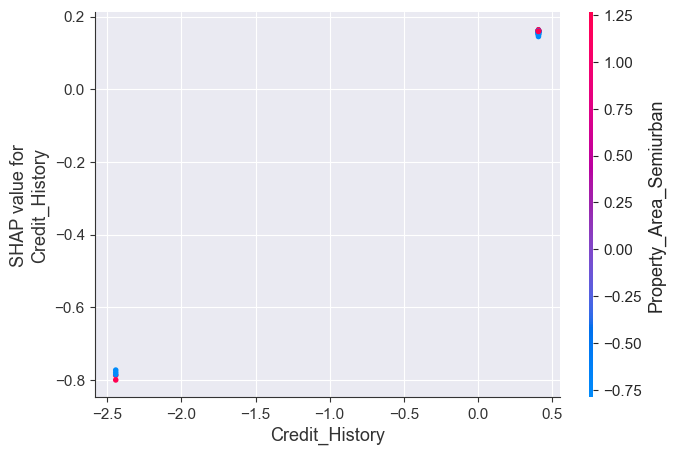

In [32]:
shap.dependence_plot(
    "ApplicantIncome",
    shap_values_nb[:, :, 1],
    X_test_scaled[:50]
)

shap.dependence_plot(
    "LoanAmount",
    shap_values_nb[:, :, 1],
    X_test_scaled[:50]
)

shap.dependence_plot(
    "Credit_History",
    shap_values_nb[:, :, 1],
    X_test_scaled[:50]
)


ApplicantIncome are un impact foarte redus.
Valorile SHAP sunt apropiate de zero, ceea ce indica o influenta slaba.

LoanAmount are o influenta minima asupra modelului.
Nu exista o relatie clara cu predictia.

Se observa o separare clara:
Credit_History = 1 are impact pozitiv puternic, iar Credit_History = 0 are impact negativ puternic.
Aceasta este variabila dominanta.

In [51]:

explainer_svm = shap.Explainer(svm_best, X_train_scaled)
shap_values_svm = explainer_svm(X_test_scaled)


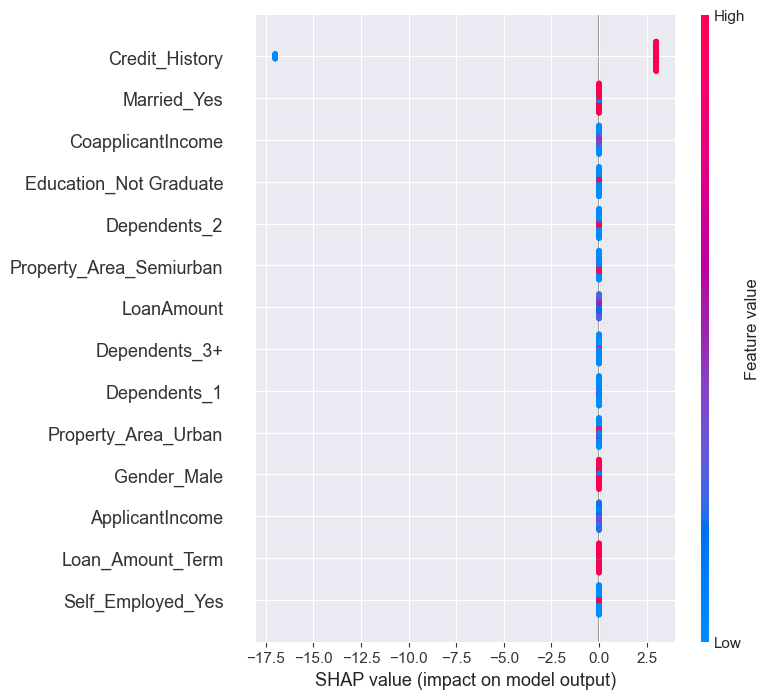

In [69]:
shap.summary_plot(shap_values_svm, X_test_scaled, show=False)

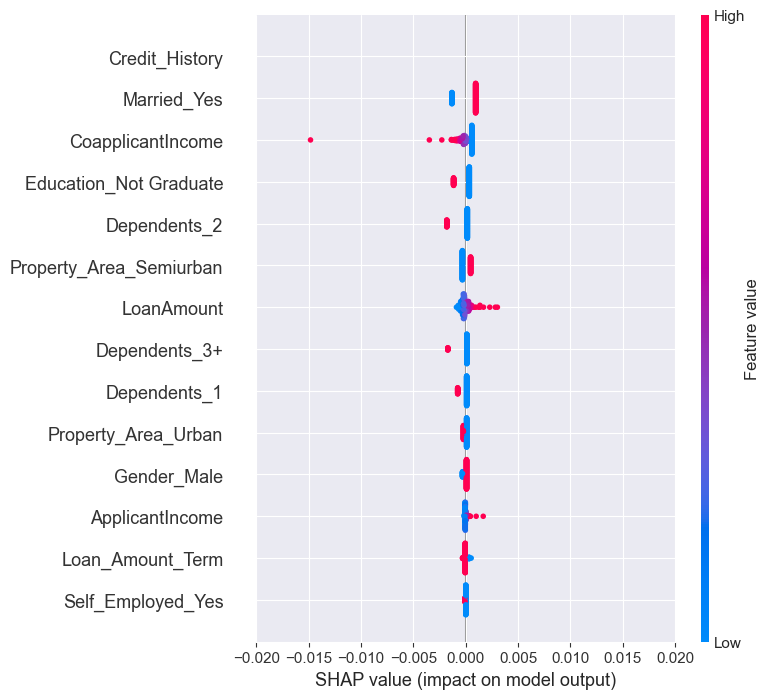

In [70]:
shap.summary_plot(shap_values_svm, X_test_scaled, show=False)

plt.xlim(-0.02, 0.02)
plt.show()

Graficul summary arata ca Credit_History este cea mai importanta variabila. Celelalte valori nu sunt prea relevante.
